# Corporate AI Disclosure EDA

Descriptive exploration of the expanded sample. Lexical candidate coverage is not validated AI topic share or adoption. Claim annotations are preliminary and not human-validated. Counts of passages, claims, and distinct applications have different units; NA stages are not zeros.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Locate the project when launching from its root or a subdirectory.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "data/document_metrics.csv").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the DIAL project or a subdirectory.")
metrics_path = PROJECT_ROOT / "data/document_metrics.csv"
metrics = pd.read_csv(metrics_path, encoding="utf-8-sig")
from matplotlib.patches import Patch

sources = pd.read_csv(PROJECT_ROOT / "data/sources_downloaded.csv", dtype="string")
sector_by_ticker = sources.set_index("ticker")["sector"].to_dict()
SECTOR_COLORS = {
    "Technology / Software": "#0072B2",
    "Retail / Consumer Commerce": "#E69F00",
    "Financial Services / Banking": "#009E73",
    "Healthcare / Pharmaceuticals": "#CC79A7",
    "Industrials / Manufacturing": "#D55E00",
    "Energy / Oil & Gas": "#6A51A3",
}

def company_colors(tickers):
    return [SECTOR_COLORS[sector_by_ticker[ticker]] for ticker in tickers]

def sector_legend(ax):
    ax.legend(handles=[Patch(facecolor=color, label=sector)
                       for sector, color in SECTOR_COLORS.items()],
              title="Research sector", loc="upper left",
              bbox_to_anchor=(1.02, 1), fontsize=8)

In [2]:
metrics

,ticker,source_file,total_word_count,ai_candidate_passage_count,ai_candidate_word_count,ai_candidate_word_share,ai_mention_count,ai_mentions_per_1000_words
0,MSFT,MSFT_10K_2026-07-29.txt,47809,101,12357,0.258466,175,3.660399
1,ADBE,ADBE_10K_2026-01-15.txt,50379,64,7922,0.157248,167,3.314873
2,CRM,CRM_10K_2026-03-02.txt,60336,72,8199,0.135889,135,2.237470
3,WMT,WMT_10K_2026-03-13.txt,53778,19,3842,0.071442,25,0.464874
4,TGT,TGT_10K_2026-03-11.txt,35511,10,1751,0.049309,15,0.422404
5,COST,COST_10K_2026-10-07.txt,31410,5,1241,0.039510,10,0.318370
6,JPM,JPM_10K_2026-02-13.txt,177035,20,1090,0.006157,30,0.169458
7,BAC,BAC_10K_2026-02-25.txt,133177,24,3966,0.029780,41,0.307861
8,C,C_10K_2026-02-20.txt,177460,20,1561,0.008796,38,0.214133
9,JNJ,JNJ_10K_2026-02-11.txt,62539,3,641,0.010250,12,0.191880


In [3]:
metrics.dtypes.to_frame(name="dtype")

,dtype
ticker,str
source_file,str
total_word_count,int64
ai_candidate_passage_count,int64
ai_candidate_word_count,int64
ai_candidate_word_share,float64
ai_mention_count,int64
ai_mentions_per_1000_words,float64


In [4]:
CONFIG = {
    "company_col": "ticker",
    "top_n": None,                 # None = all companies; or 10, 20, etc.
    "sort_by": "ai_mentions_per_1000_words",
    "ascending": False,
    "figsize": (9, 5),
    "save_figures": False,
    "output_dir": "figures",
}

df = metrics.copy()

numeric_cols = [
    "total_word_count",
    "ai_candidate_passage_count",
    "ai_candidate_word_count",
    "ai_candidate_word_share",
    "ai_mention_count",
    "ai_mentions_per_1000_words",
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df = df.sort_values(
    CONFIG["sort_by"],
    ascending=CONFIG["ascending"]
)

if CONFIG["top_n"] is not None:
    df = df.head(CONFIG["top_n"])

df = df.reset_index(drop=True)

print(f"Number of companies: {len(df)}")
display(df)

Number of companies: 18


,ticker,source_file,total_word_count,ai_candidate_passage_count,ai_candidate_word_count,ai_candidate_word_share,ai_mention_count,ai_mentions_per_1000_words
0,MSFT,MSFT_10K_2026-07-29.txt,47809,101,12357,0.258466,175,3.660399
1,ADBE,ADBE_10K_2026-01-15.txt,50379,64,7922,0.157248,167,3.314873
2,CRM,CRM_10K_2026-03-02.txt,60336,72,8199,0.135889,135,2.237470
3,WMT,WMT_10K_2026-03-13.txt,53778,19,3842,0.071442,25,0.464874
4,PFE,PFE_10K_2026-02-26.txt,95242,19,2869,0.030123,42,0.440982
5,TGT,TGT_10K_2026-03-11.txt,35511,10,1751,0.049309,15,0.422404
6,HON,HON_10K_2026-02-17.txt,66712,9,2229,0.033412,28,0.419715
7,DE,DE_10K_2025-12-18.txt,55789,15,1266,0.022693,20,0.358494
8,COST,COST_10K_2026-10-07.txt,31410,5,1241,0.039510,10,0.318370
9,BAC,BAC_10K_2026-02-25.txt,133177,24,3966,0.029780,41,0.307861


In [5]:
summary = df[numeric_cols].describe().T

summary = summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(summary.round(4))

,count,mean,std,min,25%,50%,75%,max
total_word_count,18.0,78816.3889,42761.7940,31410.0000,54280.7500,64355.5000,89147.7500,177460.0000
ai_candidate_passage_count,18.0,21.8333,28.1535,1.0000,3.2500,12.5000,20.0000,101.0000
ai_candidate_word_count,18.0,2788.6667,3404.2872,145.0000,510.5000,1413.5000,3598.7500,12357.0000
ai_candidate_word_share,18.0,0.0484,0.0689,0.0019,0.0065,0.0262,0.0469,0.2585
ai_mention_count,18.0,43.0000,55.2779,1.0000,12.5000,22.5000,40.2500,175.0000
ai_mentions_per_1000_words,18.0,0.7213,1.1192,0.0132,0.1747,0.3131,0.4363,3.6604


In [6]:
comparison = df[
    [
        CONFIG["company_col"],
        "total_word_count",
        "ai_candidate_passage_count",
        "ai_mention_count",
        "ai_mentions_per_1000_words",
        "ai_candidate_word_share",
    ]
].copy()

comparison["ai_candidate_word_share"] *= 100

comparison = comparison.rename(columns={
    "total_word_count": "Document Words",
    "ai_candidate_passage_count": "Candidate Passages",
    "ai_mention_count": "AI Mentions",
    "ai_mentions_per_1000_words": "Mentions per 1K Words",
    "ai_candidate_word_share": "Candidate Word Share (%)",
})

display(comparison.round(2))

,ticker,Document Words,Candidate Passages,AI Mentions,Mentions per 1K Words,Candidate Word Share (%)
0,MSFT,47809,101,175,3.66,25.85
1,ADBE,50379,64,167,3.31,15.72
2,CRM,60336,72,135,2.24,13.59
3,WMT,53778,19,25,0.46,7.14
4,PFE,95242,19,42,0.44,3.01
5,TGT,35511,10,15,0.42,4.93
6,HON,66712,9,28,0.42,3.34
7,DE,55789,15,20,0.36,2.27
8,COST,31410,5,10,0.32,3.95
9,BAC,133177,24,41,0.31,2.98


In [7]:
def plot_bar(data, column, title=None, xlabel=None,
             multiplier=1, decimals=2):

    plot_df = data.sort_values(column, ascending=True)

    fig, ax = plt.subplots(figsize=(CONFIG["figsize"][0], max(CONFIG["figsize"][1], len(plot_df) * 0.35)))

    values = plot_df[column] * multiplier

    bars = ax.barh(
        plot_df[CONFIG["company_col"]].astype(str),
        values,
        color=company_colors(plot_df[CONFIG["company_col"]])
    )

    ax.set_title(title or column)
    ax.set_xlabel(xlabel or column)
    ax.set_ylabel("")

    ax.bar_label(
        bars,
        fmt=f"%.{decimals}f",
        padding=4
    )

    ax.set_xlim(0, max(values.max() * 1.2, 1) if len(values) else 1)

    sector_legend(ax)
    plt.tight_layout()

    if CONFIG["save_figures"]:
        output_dir = PROJECT_ROOT / CONFIG["output_dir"]
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            output_dir / f"{column}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

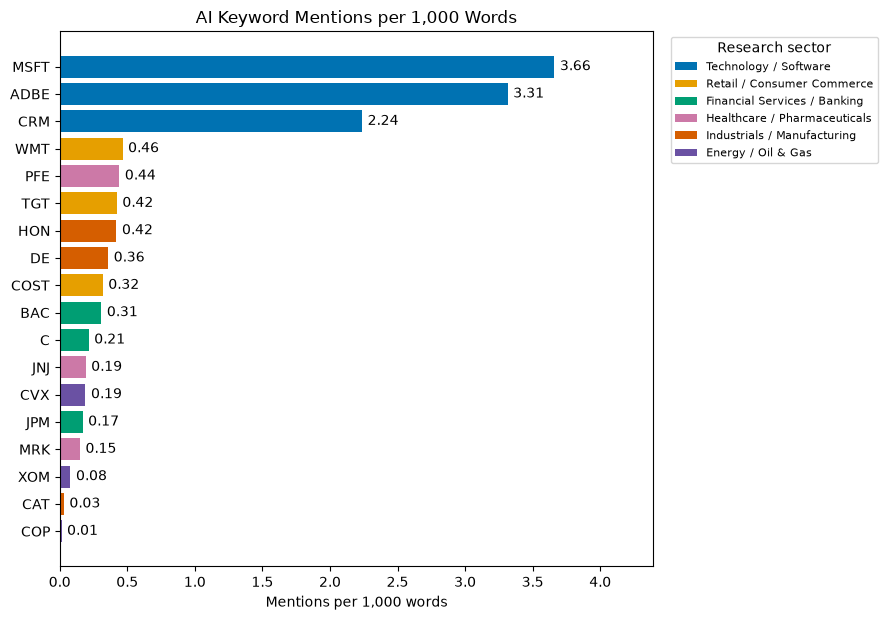

In [8]:
plot_bar(
    df,
    column="ai_mentions_per_1000_words",
    title="AI Keyword Mentions per 1,000 Words",
    xlabel="Mentions per 1,000 words"
)

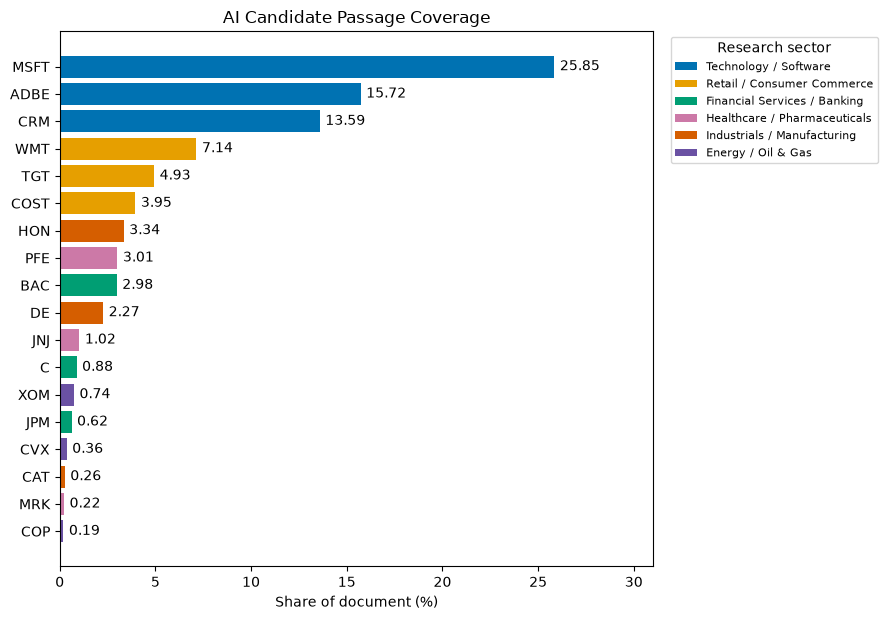

In [9]:
plot_bar(
    df,
    column="ai_candidate_word_share",
    title="AI Candidate Passage Coverage",
    xlabel="Share of document (%)",
    multiplier=100
)

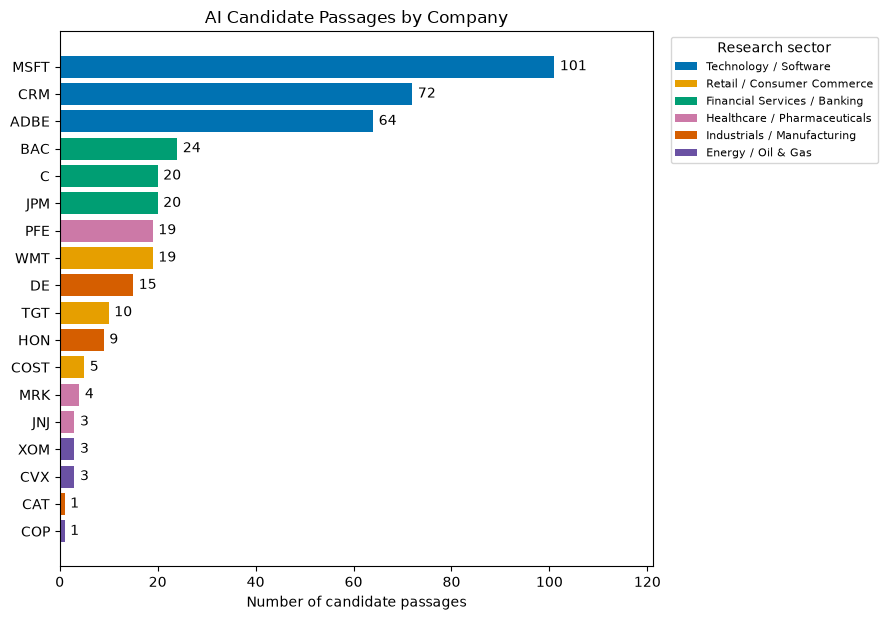

In [10]:
plot_bar(
    df,
    column="ai_candidate_passage_count",
    title="AI Candidate Passages by Company",
    xlabel="Number of candidate passages",
    decimals=0
)

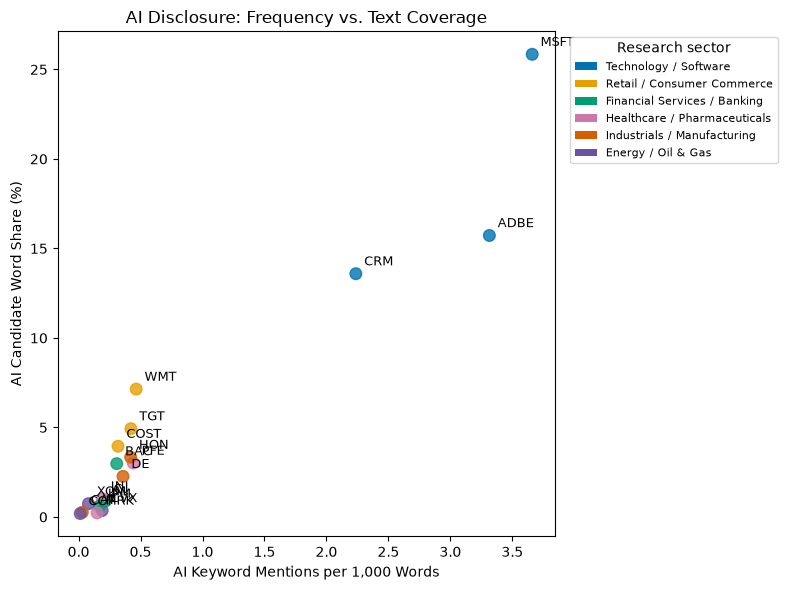

In [11]:
x_col = "ai_mentions_per_1000_words"
y_col = "ai_candidate_word_share"

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df[x_col],
    df[y_col] * 100,
    s=70,
    alpha=0.8,
    c=company_colors(df[CONFIG["company_col"]])
)

for _, row in df.iterrows():
    ax.annotate(
        str(row[CONFIG["company_col"]]),
        (row[x_col], row[y_col] * 100),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel("AI Keyword Mentions per 1,000 Words")
ax.set_ylabel("AI Candidate Word Share (%)")
ax.set_title("AI Disclosure: Frequency vs. Text Coverage")

sector_legend(ax)
plt.tight_layout()
plt.show()

In [12]:
ANNOTATION_CONFIG = {
    "path": PROJECT_ROOT / "data/ai_annotations.csv",
    "company_col": "ticker",
    "period_col": "report_period",
    "stage_col": "adoption_stage",
    "figsize": (12, 6),
}

annotation_path = ANNOTATION_CONFIG["path"]
annotations = pd.read_csv(annotation_path, dtype="string", keep_default_na=False)
print(f"Loaded {len(annotations)} preliminary annotation rows; not human-validated.")
display(annotations[["claim_id", "ticker", "ai_relevance", "adoption_stage"]].head())

Loaded 447 preliminary annotation rows; not human-validated.


,claim_id,ticker,ai_relevance,adoption_stage
0,MSFT_claim_eaa8e874c2f10f291c6d,MSFT,substantive,1
1,MSFT_claim_c3c9806cf79895597c4a,MSFT,substantive,1
2,MSFT_claim_635f838780b8b65a4adc,MSFT,context_only,NA
3,MSFT_claim_fa047e45bee1cf3eb338,MSFT,substantive,NA
4,MSFT_claim_91a64df7294e14647cce,MSFT,substantive,1


In [13]:
ann = pd.DataFrame()

EXPECTED_COLUMNS = {
    "ticker",
    "passage_id",
    "claim_id",
    "ai_relevance",
    "adoption_stage",
    "strategy_specificity",
    "application_scope",
    "strategic_orientation",
    "reported_deployment",
    "quantified_outcome",
    "coding_confidence",
    "needs_human_review",
}

if not annotations.empty:

    missing_cols = EXPECTED_COLUMNS - set(annotations.columns)

    if missing_cols:
        raise ValueError(f"Missing expected columns: {sorted(missing_cols)}")

    # Work on a copy
    ann = annotations.copy()

    # Normalize common missing values
    ann = ann.replace(
        ["", "NA", "N/A", "null", "None"],
        pd.NA
    )

    # Convert numerical metrics
    for col in ["adoption_stage", "strategy_specificity"]:
        if col in ann.columns:
            ann[col] = pd.to_numeric(
                ann[col],
                errors="coerce"
            )

    # Consistent text labels
    for col in [
        "ai_relevance",
        "coding_confidence",
        "reported_deployment",
        "quantified_outcome",
    ]:
        if col in ann.columns:
            ann[col] = ann[col].str.lower().str.strip()

    display(
        ann.dtypes.to_frame("dtype")
    )

,dtype
claim_id,string
passage_id,string
ticker,string
report_period,string
source_file,string
source_line,string
evidence_quote,string
ai_relevance,string
focal_firm_evidence,string
actor,string


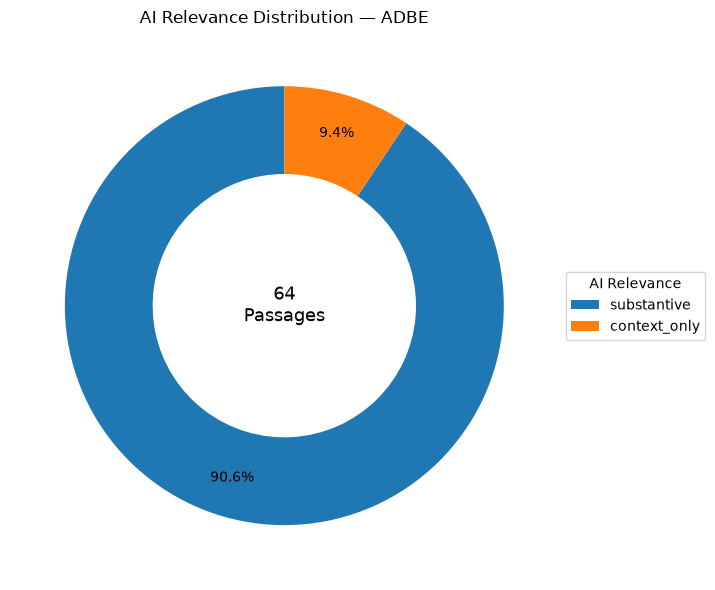

ai_relevance
substantive     58
context_only     6
Name: count, dtype: int64[pyarrow]

In [14]:
if not ann.empty:

    company_col = ANNOTATION_CONFIG["company_col"]

    companies = sorted(ann[company_col].dropna().unique())

    # Change this to any company in the dataset
    SELECTED_COMPANY = companies[0]

    company_data = ann[
        ann[company_col] == SELECTED_COMPANY
    ].copy()

    # Count unique passages, not split claims.
    relevance_order = [
        "substantive",
        "context_only",
        "irrelevant",
        "uncertain"
    ]

    passage_relevance = (
        company_data
        .groupby("passage_id")["ai_relevance"]
        .agg(
            lambda s: (
                "substantive" if "substantive" in s.values
                else "uncertain" if "uncertain" in s.values
                else "context_only" if "context_only" in s.values
                else "irrelevant"
            )
        )
    )

    relevance_counts = (
        passage_relevance
        .value_counts()
        .reindex(relevance_order, fill_value=0)
    )

    relevance_counts = relevance_counts[
        relevance_counts > 0
    ]

    if relevance_counts.empty:
        print("No relevance data available.")
    else:
        fig, ax = plt.subplots(figsize=(7, 6))

        wedges, _, autotexts = ax.pie(
            relevance_counts,
            autopct=lambda p: f"{p:.1f}%" if p >= 4 else "",
            startangle=90,
            pctdistance=0.82,
            wedgeprops={"width": 0.4}
        )

        ax.text(
            0, 0,
            f"{len(passage_relevance)}\nPassages",
            ha="center",
            va="center",
            fontsize=13
        )

        ax.legend(
            wedges,
            relevance_counts.index,
            title="AI Relevance",
            loc="center left",
            bbox_to_anchor=(1, 0.5)
        )

        ax.set_title(
            f"AI Relevance Distribution — {SELECTED_COMPANY}"
        )

        plt.tight_layout()
        plt.show()

    display(relevance_counts)

reported_adoption_stage,1,2,3,4,5,NA
ticker,,,,,,
ADBE,5,1,0,30,0,37
BAC,0,1,0,1,0,23
C,1,0,0,1,0,20
CAT,0,0,0,0,0,1
COP,0,0,0,0,0,1
COST,0,0,0,0,0,5
CRM,6,0,0,25,0,50
CVX,0,0,0,2,0,3
DE,1,1,0,3,0,11


reported_adoption_stage,1,2,3,4,5,NA
ticker,,,,,,
ADBE,6.85,1.37,0.0,41.10,0.0,50.68
BAC,0.00,4.00,0.0,4.00,0.0,92.00
C,4.55,0.00,0.0,4.55,0.0,90.91
CAT,0.00,0.00,0.0,0.00,0.0,100.00
COP,0.00,0.00,0.0,0.00,0.0,100.00
COST,0.00,0.00,0.0,0.00,0.0,100.00
CRM,7.41,0.00,0.0,30.86,0.0,61.73
CVX,0.00,0.00,0.0,40.00,0.0,60.00
DE,6.25,6.25,0.0,18.75,0.0,68.75


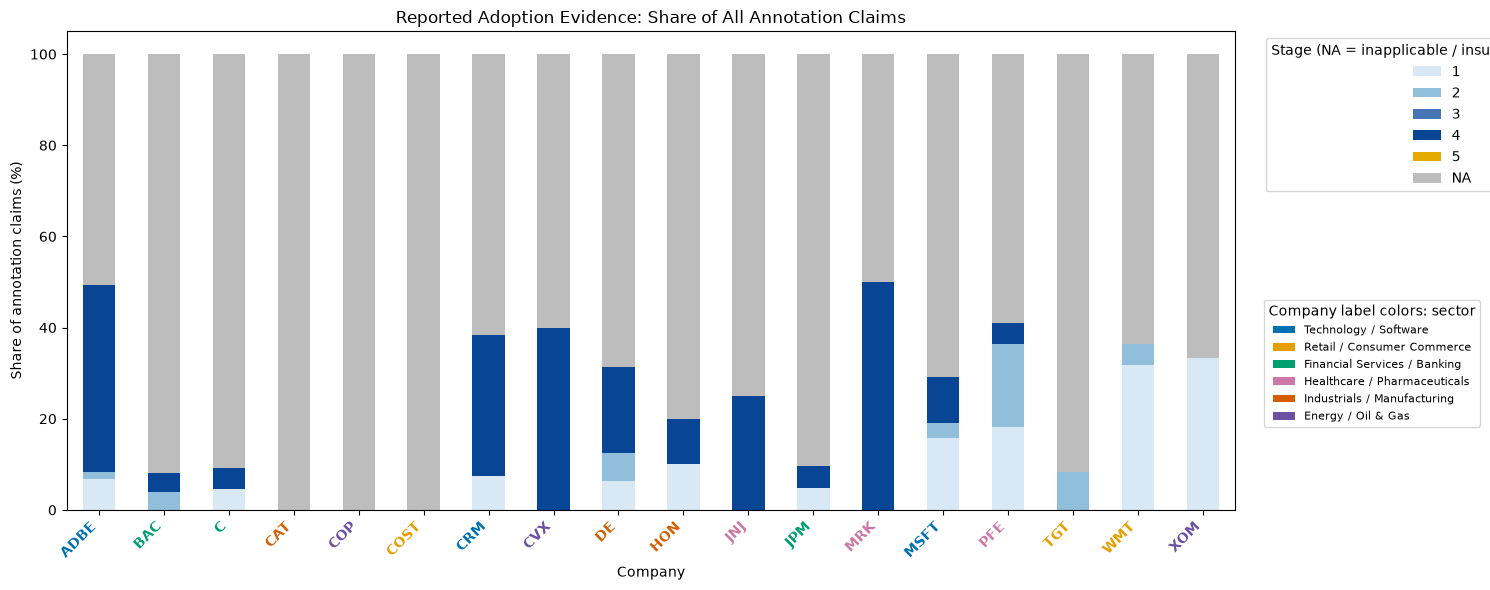

In [15]:
# Count claims, including stage-ineligible / insufficient-evidence NA records.
# This is a disclosure distribution, not a company maturity score.
if not ann.empty:
    stage_order = ["1", "2", "3", "4", "5", "NA"]
    stage_labels = ann["adoption_stage"].astype("Int64").astype("string").fillna("NA")
    stage_table = pd.crosstab(ann["ticker"], stage_labels).reindex(
        index=sorted(metrics["ticker"].unique()), columns=stage_order, fill_value=0
    )
    stage_table.columns.name = "reported_adoption_stage"
    stage_pct = stage_table.div(stage_table.sum(axis=1).replace(0, np.nan), axis=0) * 100
    display(stage_table)
    display(stage_pct.round(2))
    stage_colors = ["#d9e8f5", "#91bfdb", "#4575b4", "#084594", "#e6ab02", "#bdbdbd"]
    ax = stage_pct.plot(kind="bar", stacked=True,
                        figsize=(15, 6), color=stage_colors)
    for label in ax.get_xticklabels():
        label.set_color(SECTOR_COLORS[sector_by_ticker[label.get_text()]])
        label.set_fontweight("bold")
    plt.title("Reported Adoption Evidence: Share of All Annotation Claims")
    plt.xlabel("Company")
    plt.ylabel("Share of annotation claims (%)")
    plt.legend(title="Stage (NA = inapplicable / insufficient evidence)",
               bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    stage_legend = ax.get_legend()
    ax.add_artist(stage_legend)
    ax.legend(handles=[Patch(facecolor=color, label=sector)
                       for sector, color in SECTOR_COLORS.items()],
              title="Company label colors: sector", loc="upper left",
              bbox_to_anchor=(1.02, 0.45), fontsize=8)
    plt.tight_layout()
    plt.show()

,adoption_stage,count,mean,median
0,1,46,1.83,2.0
1,2,13,3.31,3.0
2,4,80,2.9,3.0


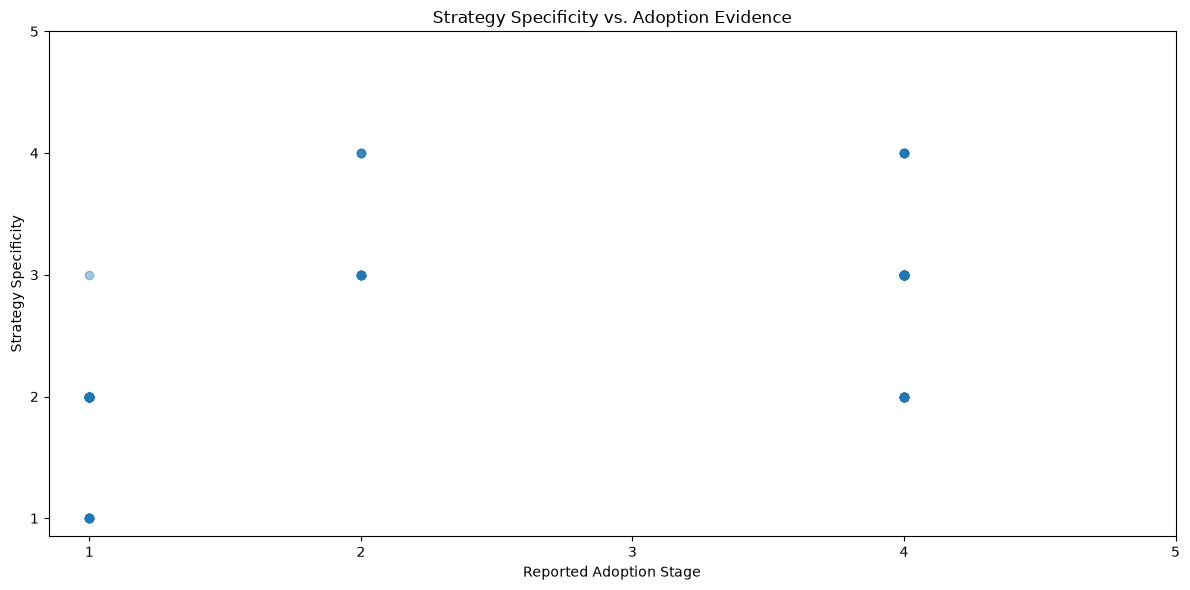

In [16]:
if not annotations.empty:

    specificity_data = ann.dropna(
        subset=["adoption_stage", "strategy_specificity"]
    ).copy()

    specificity_summary = (
        specificity_data
        .groupby("adoption_stage")["strategy_specificity"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .sort_values("adoption_stage")
    )

    display(specificity_summary.round(2))

    fig, ax = plt.subplots(
        figsize=ANNOTATION_CONFIG["figsize"]
    )

    ax.scatter(
        specificity_data["adoption_stage"],
        specificity_data["strategy_specificity"],
        alpha=0.4
    )

    ax.set_xlabel("Reported Adoption Stage")
    ax.set_ylabel("Strategy Specificity")
    ax.set_title("Strategy Specificity vs. Adoption Evidence")

    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_yticks([1, 2, 3, 4, 5])

    plt.tight_layout()
    plt.show()